# Flight Delay Prediction: Random Forest & XGBoost (standalone)

Independent take on the tree-ensemble models for the [Zindi Flight Delay Prediction Challenge](https://zindi.africa/competitions/flight-delay-prediction-challenge) (Tunisair), built separately from `04_flight_delay_modeling.ipynb` on its own branch (not merged into `main`).

This notebook is self-contained: it loads `data/Train.csv` directly, does its own light feature engineering and time-based split, re-derives the same baselines for reference, and then focuses on **Random Forest** and **XGBoost** with feature importance and a model comparison.

## Load & Clean Data

Same date-parsing fix as the baseline notebook: `STA` uses dots (`12.55.00`) instead of colons and needs normalising before `pd.to_datetime` can parse it; unparseable values are coerced to `NaT` rather than left as object dtype.

In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv("data/Train.csv")

train["STA"] = train["STA"].str.replace(".", ":", regex=False)
for col in ["DATOP", "STD", "STA"]:
    train[col] = pd.to_datetime(train[col], errors="coerce")

train.head()

,ID,DATOP,FLTID,DEPSTN,ARRSTN,STD,STA,STATUS,AC,target
0,train_id_0,2016-01-03,TU 0712,CMN,TUN,2016-01-03 10:30:00,2016-01-03 12:55:00,ATA,TU 32AIMN,260.0
1,train_id_1,2016-01-13,TU 0757,MXP,TUN,2016-01-13 15:05:00,2016-01-13 16:55:00,ATA,TU 31BIMO,20.0
2,train_id_2,2016-01-16,TU 0214,TUN,IST,2016-01-16 04:10:00,2016-01-16 06:45:00,ATA,TU 32AIMN,0.0
3,train_id_3,2016-01-17,TU 0480,DJE,NTE,2016-01-17 14:10:00,2016-01-17 17:00:00,ATA,TU 736IOK,0.0
4,train_id_4,2016-01-17,TU 0338,TUN,ALG,2016-01-17 14:30:00,2016-01-17 15:50:00,ATA,TU 320IMU,22.0


## Feature Engineering

Basic time and route features: hour/day-of-week/month of scheduled departure, scheduled block time, and the route as a single categorical.

In [2]:
def add_features(df):
    df = df.copy()
    df["hour"] = df["STD"].dt.hour
    df["dow"] = df["STD"].dt.dayofweek
    df["month"] = df["STD"].dt.month
    df["block_min"] = (df["STA"] - df["STD"]).dt.total_seconds() / 60
    df["block_min"] = df["block_min"].fillna(df["block_min"].median())
    df["route"] = df["DEPSTN"].astype(str) + "_" + df["ARRSTN"].astype(str)
    return df

train = add_features(train)

cat_cols = ["route", "DEPSTN", "ARRSTN"]
num_cols = ["hour", "dow", "month", "block_min"]

train[cat_cols + num_cols + ["target"]].head()

,route,DEPSTN,ARRSTN,hour,dow,month,block_min,target
0,CMN_TUN,CMN,TUN,10,6,1,145.0,260.0
1,MXP_TUN,MXP,TUN,15,2,1,110.0,20.0
2,TUN_IST,TUN,IST,4,5,1,155.0,0.0
3,DJE_NTE,DJE,NTE,14,6,1,170.0,0.0
4,TUN_ALG,TUN,ALG,14,6,1,80.0,22.0


## Time-Based Train / Validation Split

Earliest ~80% of dates for training, most recent ~20% held out for validation -- avoids leaking "future" information into features computed over time, and mirrors predicting delays for flights that haven't happened yet.

In [3]:
train = train.sort_values("DATOP")

cutoff = train["DATOP"].quantile(0.8)
X_train, X_val = train[train["DATOP"] <= cutoff], train[train["DATOP"] > cutoff]

print(f"Train: {len(X_train)} rows up to {X_train['DATOP'].max().date()}")
print(f"Validation: {len(X_val)} rows from {X_val['DATOP'].min().date()} onward")

Train: 86352 rows up to 2018-06-01
Validation: 21481 rows from 2018-06-02 onward


## Reference Baselines

Quick constant-mean and route-mean baselines, purely as a floor to compare the tree ensembles against.

In [4]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

baseline0_pred = np.full(len(X_val), X_train["target"].mean())
rmse_baseline0 = rmse(X_val["target"], baseline0_pred)

route_mean = X_train.groupby("route")["target"].mean()
global_mean = X_train["target"].mean()
baseline1_pred = X_val["route"].map(route_mean).fillna(global_mean)
rmse_baseline1 = rmse(X_val["target"], baseline1_pred)

print(f"Baseline 0 (constant mean) validation RMSE: {rmse_baseline0:.2f}")
print(f"Baseline 1 (route mean) validation RMSE:    {rmse_baseline1:.2f}")

Baseline 0 (constant mean) validation RMSE: 142.10
Baseline 1 (route mean) validation RMSE:    139.60


## Random Forest

An ensemble of de-correlated decision trees, each trained on a bootstrap sample with a random subset of features per split, averaged together. Captures non-linear effects and interactions without hand-engineering them.

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

rf_model = Pipeline([
    ("preprocess", preprocess),
    ("reg", RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42,
    )),
])
rf_model.fit(X_train[cat_cols + num_cols], X_train["target"])

rf_pred = rf_model.predict(X_val[cat_cols + num_cols])
rmse_rf = rmse(X_val["target"], rf_pred)

print(f"Random Forest validation RMSE: {rmse_rf:.2f}")

Random Forest validation RMSE: 139.07


### Random Forest Feature Importance

In [6]:
rf_feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
rf_importances = pd.Series(
    rf_model.named_steps["reg"].feature_importances_, index=rf_feature_names
).sort_values(ascending=False)

rf_importances.head(15)

remainder__month        0.222018
remainder__hour         0.196673
remainder__block_min    0.139561
remainder__dow          0.089380
cat__route_TUN_TUN      0.087124
cat__route_SXF_TUN      0.018370
cat__route_HAM_DJE      0.013056
cat__route_MIR_CDG      0.011980
cat__DEPSTN_CZL         0.010898
cat__route_ALG_TUN      0.009148
cat__route_DJE_DJE      0.008393
cat__DEPSTN_TUN         0.007110
cat__route_TUN_ALG      0.006416
cat__route_CDG_TUN      0.005582
cat__DEPSTN_IST         0.004974
dtype: float64

## XGBoost

A gradient-boosted tree ensemble: trees are added sequentially, each fit to correct the residual errors of the ensemble so far, rather than averaged independently like Random Forest. Often the strongest tabular model for a skewed, tail-heavy target like flight delay.

In [7]:
from xgboost import XGBRegressor

xgb_model = Pipeline([
    ("preprocess", preprocess),
    ("reg", XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )),
])
xgb_model.fit(X_train[cat_cols + num_cols], X_train["target"])

xgb_pred = xgb_model.predict(X_val[cat_cols + num_cols])
rmse_xgb = rmse(X_val["target"], xgb_pred)

print(f"XGBoost validation RMSE: {rmse_xgb:.2f}")

XGBoost validation RMSE: 138.15


### XGBoost Feature Importance

In [8]:
xgb_feature_names = xgb_model.named_steps["preprocess"].get_feature_names_out()
xgb_importances = pd.Series(
    xgb_model.named_steps["reg"].feature_importances_, index=xgb_feature_names
).sort_values(ascending=False)

xgb_importances.head(15)

cat__route_TUN_TUN    0.037559
cat__route_DJE_TUN    0.020438
cat__route_TUN_ORY    0.019608
cat__route_MRS_TUN    0.013333
cat__route_TUN_SVO    0.013315
cat__ARRSTN_ORY       0.011522
cat__route_ALG_TUN    0.010986
cat__route_TUN_SXF    0.010787
cat__DEPSTN_SFA       0.009109
cat__route_DJE_DJE    0.008788
cat__route_TUN_IST    0.008773
cat__route_TUN_ALG    0.008716
cat__DEPSTN_DJE       0.008395
cat__route_MIR_MRS    0.008289
cat__DEPSTN_ALG       0.008170
dtype: float32

## Compare All Models

In [9]:
results = pd.DataFrame({
    "model": ["Constant mean", "Route mean", "Random Forest", "XGBoost"],
    "validation_rmse": [rmse_baseline0, rmse_baseline1, rmse_rf, rmse_xgb],
}).sort_values("validation_rmse").reset_index(drop=True)

results

,model,validation_rmse
0,XGBoost,138.145406
1,Random Forest,139.073117
2,Route mean,139.597900
3,Constant mean,142.102752


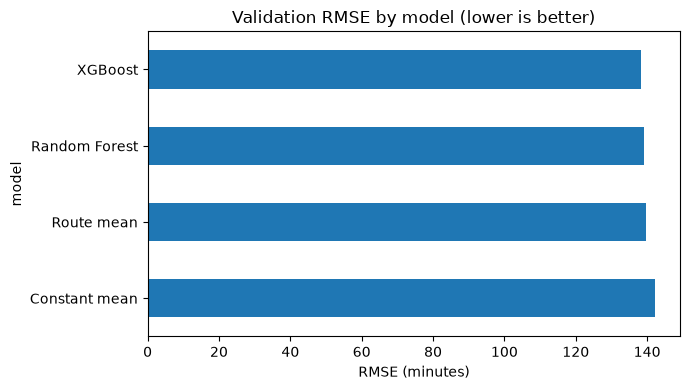

In [10]:
import matplotlib.pyplot as plt

ax = results.set_index("model")["validation_rmse"].plot(
    kind="barh", figsize=(7, 4), title="Validation RMSE by model (lower is better)"
)
ax.set_xlabel("RMSE (minutes)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Notes

- Both models use one-hot encoded categoricals via the same `ColumnTransformer`, for an apples-to-apples comparison.
- Hyperparameters above are reasonable defaults, not tuned -- a hyperparameter search (`RandomizedSearchCV`/`GridSearchCV` with `TimeSeriesSplit`) is the natural next step before treating either result as final.
- This notebook lives on its own branch (`random-forest-xgboost-standalone`) and is not merged into `main` -- it's a separate, independent pass at the same problem `04_flight_delay_modeling.ipynb` already covers.